<a href="https://colab.research.google.com/github/RaniaChaudhry511/Unsupervised-Learning/blob/main/PCA_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#INTRODUCTION

This project applies Principal Component Analysis (PCA), an unsupervised
learning algorithm, on the Spotify Tracks Dataset from Kaggle. The dataset
contains 1,14,000 songs across 114 genres with audio features like danceability,
energy, tempo, valence, and more. Since these features are highly correlated,
PCA is used to reduce dimensions and uncover hidden patterns. The goal is to
group similar songs into meaningful clusters — without using any labels.

#STEP 1: DATA LOADING AND UNDERSTANDING

In [ ]:
# ============================================================
#        SPOTIFY TRACKS - PCA UNSUPERVISED LEARNING
# ============================================================

# 1. DATA HANDLING
import numpy as np
import pandas as pd

# 2. DATA VISUALIZATION (EDA)
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

# 3. PREPROCESSING & FEATURE ENGINEERING
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

# 4. DIMENSIONALITY REDUCTION (PCA - Main Algorithm)
from sklearn.decomposition import PCA

# 5. CLUSTERING (Pattern Analysis ke liye)
from sklearn.cluster import KMeans, AgglomerativeClustering

# 6. MODEL EVALUATION
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics import silhouette_samples

# 7. HYPERPARAMETER TUNING
from sklearn.model_selection import GridSearchCV

# 8. WARNINGS SUPPRESS
import warnings
warnings.filterwarnings('ignore')

print(" All Libraries Imported Successfully!")

 All Libraries Imported Successfully!


In [ ]:
df = pd.read_csv('/content/dataset.csv')

df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,-6.746,0,0.143,0.032,0.000,0.358,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,1,-17.235,1,0.076,0.924,0.000,0.101,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,0,-9.734,1,0.056,0.210,0.000,0.117,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.060,0,-18.515,1,0.036,0.905,0.000,0.132,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.443,2,-9.681,1,0.053,0.469,0.000,0.083,0.167,119.949,4,acoustic


In [ ]:
df.shape

(114000, 21)

In [ ]:
df.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')

In [ ]:
df.dtypes

,0
Unnamed: 0,int64
track_id,object
artists,object
album_name,object
track_name,object
popularity,int64
duration_ms,int64
explicit,bool
danceability,float64
energy,float64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
track_id,0
artists,1
album_name,1
track_name,1
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000
mean,56999.500,33.239,228029.153,0.567,0.641,5.309,-8.259,0.638,0.085,0.315,0.156,0.214,0.474,122.148,3.904
std,32909.110,22.305,107297.713,0.174,0.252,3.560,5.029,0.481,0.106,0.333,0.310,0.190,0.259,29.978,0.433
min,0.000,0.000,0.000,0.000,0.000,0.000,-49.531,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,28499.750,17.000,174066.000,0.456,0.472,2.000,-10.013,0.000,0.036,0.017,0.000,0.098,0.260,99.219,4.000
50%,56999.500,35.000,212906.000,0.580,0.685,5.000,-7.004,1.000,0.049,0.169,0.000,0.132,0.464,122.017,4.000
75%,85499.250,50.000,261506.000,0.695,0.854,8.000,-5.003,1.000,0.085,0.598,0.049,0.273,0.683,140.071,4.000
max,113999.000,100.000,5237295.000,0.985,1.000,11.000,4.532,1.000,0.965,0.996,1.000,1.000,0.995,243.372,5.000


#STEP 2: DATA CLEANING

We dropped the 'Unnamed: 0' column because it was just a row number, not useful data.

Only 3 rows had missing values out of 114,000, so we simply dropped them.



In [ ]:
df.dropna(inplace=True)
df.drop(columns=['Unnamed: 0'], inplace=True)
print("Shape after cleaning:", df.shape)

Shape after cleaning: (113999, 20)


In [ ]:
numeric_cols = ['popularity', 'duration_ms', 'danceability', 'energy', 'loudness',
                'speechiness', 'acousticness', 'instrumentalness', 'liveness',
                'valence', 'tempo']

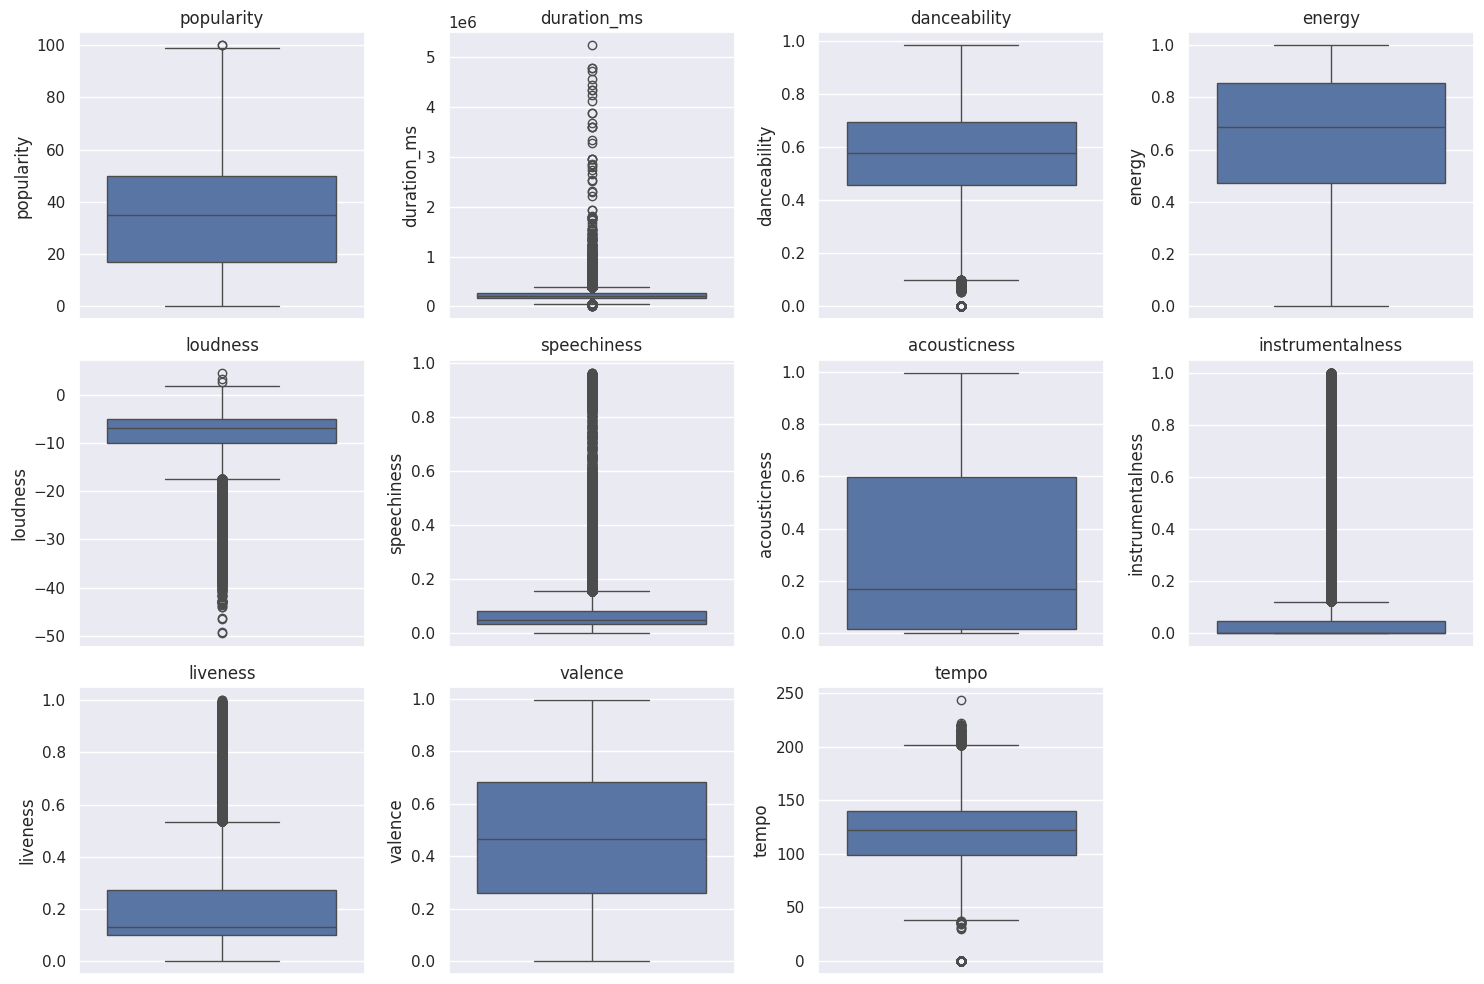

In [ ]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(3, 4, i+1)
    sns.boxplot(df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [ ]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))]
    print(f"{col}: {len(outliers)} outliers")

popularity: 2 outliers
duration_ms: 5616 outliers
danceability: 620 outliers
energy: 0 outliers
loudness: 6173 outliers
speechiness: 13211 outliers
acousticness: 0 outliers
instrumentalness: 25246 outliers
liveness: 8642 outliers
valence: 0 outliers
tempo: 617 outliers


Since this is a large dataset with 113,999 songs, having a few outliers
does not affect PCA significantly. Features like instrumentalness,
speechiness and liveness have natural skewed distributions, not true
outliers. So we decided to keep the data as it is and move forward.

#STEP 3: EDA

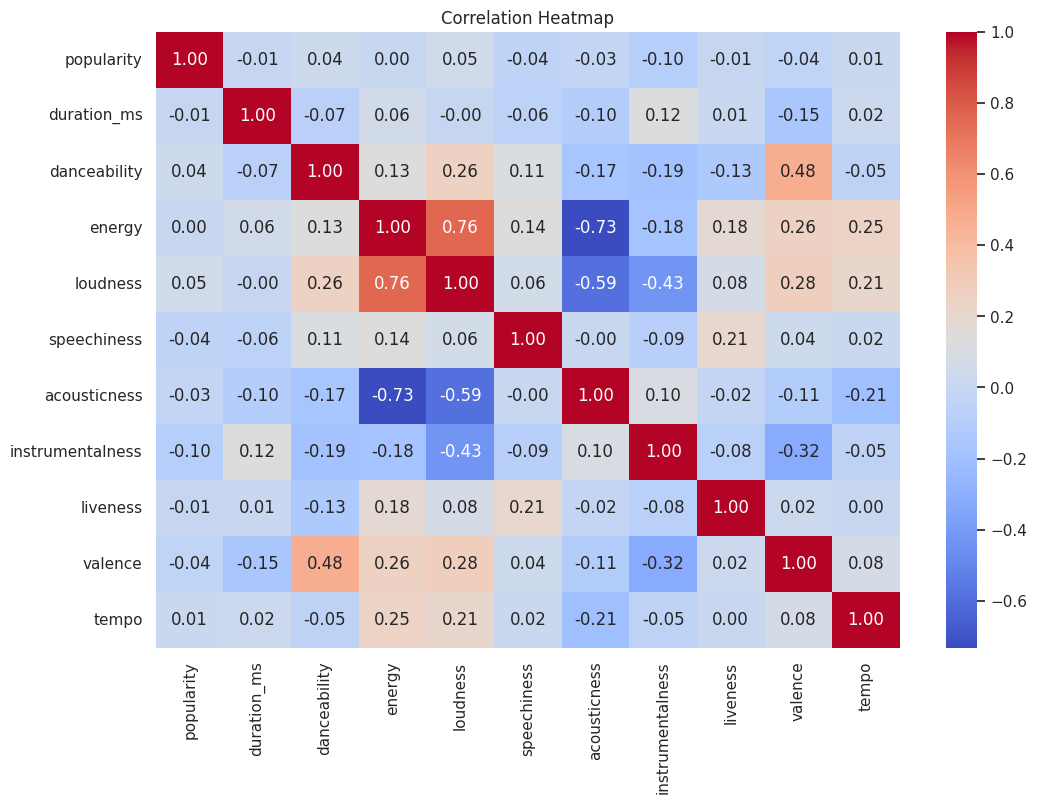

In [ ]:
# Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

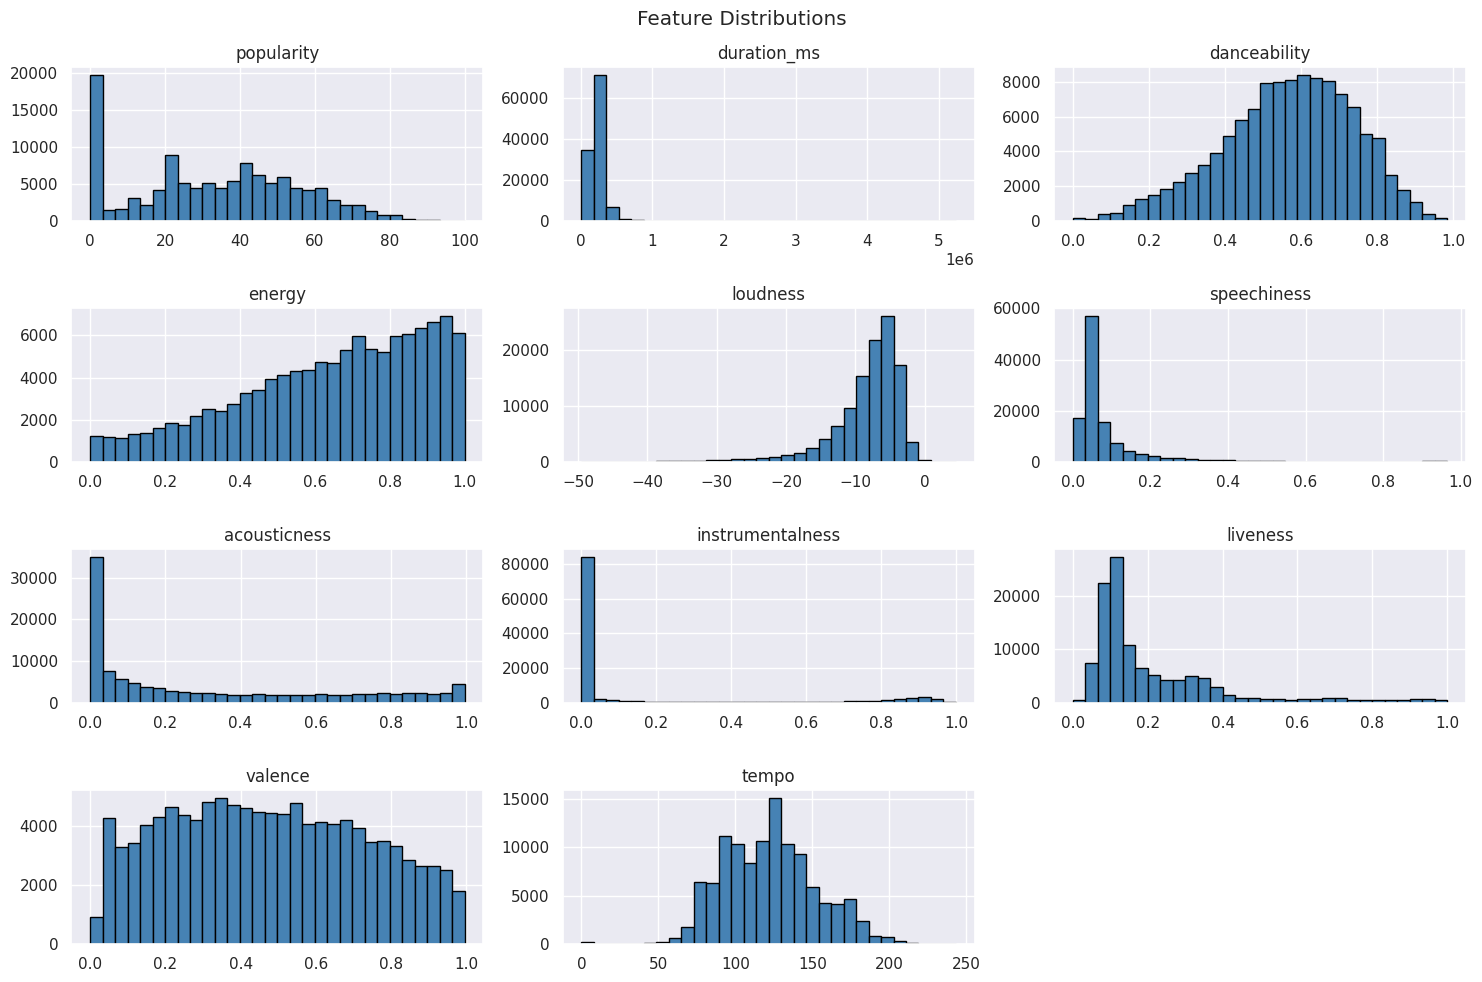

In [ ]:
# Histogram
df[numeric_cols].hist(figsize=(15, 10), bins=30, color='steelblue', edgecolor='black')
plt.suptitle('Feature Distributions')
plt.tight_layout()
plt.show()

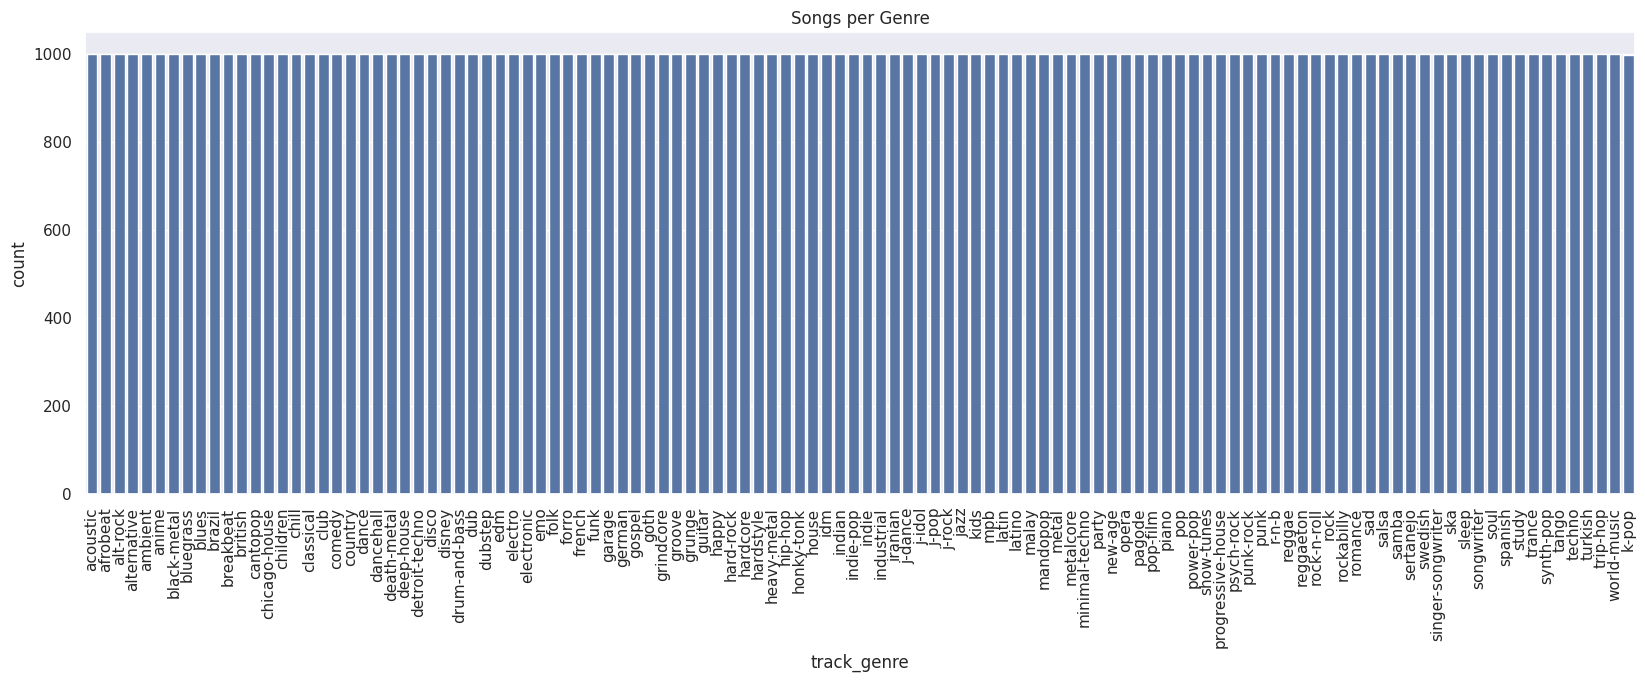

In [ ]:
# Countplot
plt.figure(figsize=(20, 6))
sns.countplot(data=df, x='track_genre', order=df['track_genre'].value_counts().index)
plt.xticks(rotation=90)
plt.title('Songs per Genre')
plt.show()

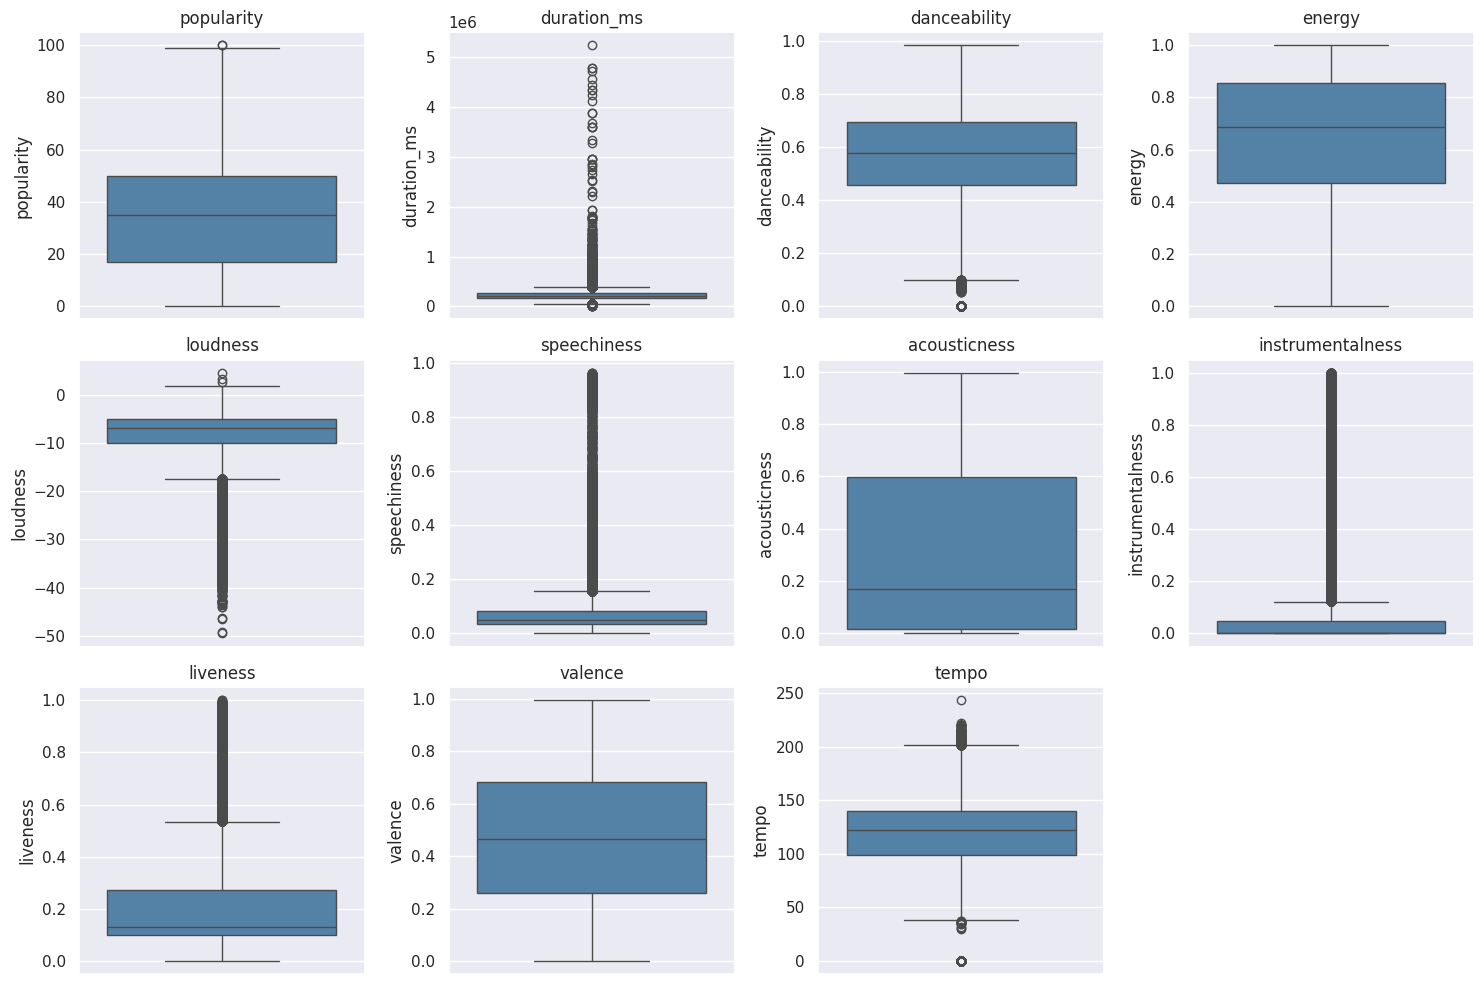

In [ ]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(3, 4, i+1)
    sns.boxplot(df[col], color='steelblue')
    plt.title(col)
plt.tight_layout()
plt.show()

EDA showed that danceability and valence have balanced distributions.
Speechiness and instrumentalness are heavily right skewed which is
natural for music data. All 114 genres have exactly 1000 songs each
showing a perfectly balanced dataset. Energy and loudness are
correlated which confirms that PCA will be useful here.


#STEP 4: FEATURE ENGINEERING

In [ ]:

df['explicit'] = df['explicit'].astype(int)

features = ['danceability', 'energy', 'loudness', 'speechiness',
            'acousticness', 'instrumentalness', 'liveness',
            'valence', 'tempo', 'popularity', 'duration_ms', 'explicit']

X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Shape:", X_scaled.shape)

Shape: (113999, 12)


Boolean column explicit was converted to integer. Only meaningful
audio features were selected for PCA. StandardScaler was applied
to bring all features to the same scale since PCA is sensitive
to feature magnitudes.


#STEP 5: MODEL SELECTION

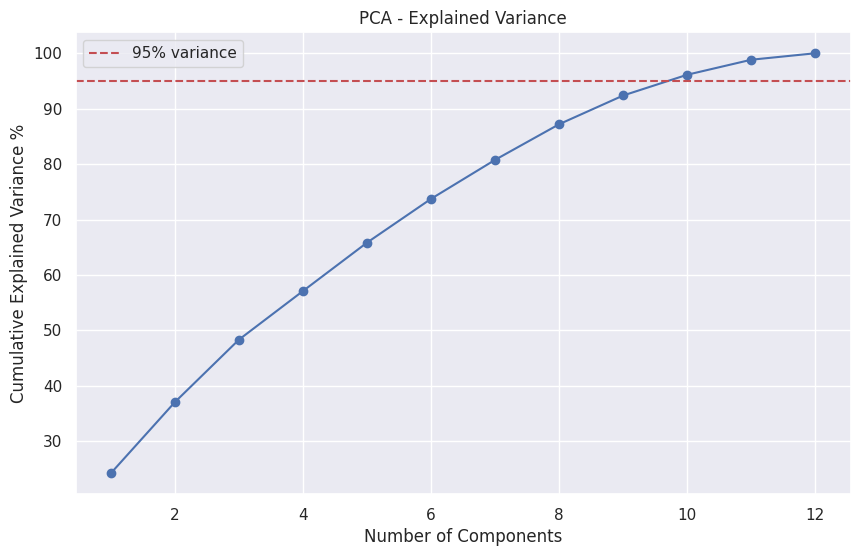

Variance per component: [24.23 12.83 11.27  8.77  8.73  7.9   7.03  6.43  5.18  3.74  2.71  1.17]


In [ ]:
pca = PCA()
pca.fit(X_scaled)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 13), np.cumsum(pca.explained_variance_ratio_) * 100, marker='o')
plt.axhline(y=95, color='r', linestyle='--', label='95% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance %')
plt.title('PCA - Explained Variance')
plt.legend()
plt.show()

print("Variance per component:", np.round(pca.explained_variance_ratio_ * 100, 2))

PCA explained variance analysis showed that 7 components capture
80% of the total variance in the data. We selected 7 components
as the optimal number to balance dimensionality reduction while
retaining enough information for meaningful clustering.

#STEP 6: MODEL TRAINING

In [ ]:
pca = PCA(n_components=7)
X_pca = pca.fit_transform(X_scaled)

print("Original Shape:", X_scaled.shape)
print("Reduced Shape:", X_pca.shape)

Original Shape: (113999, 12)
Reduced Shape: (113999, 7)


#STEP 7: CLUSTER ANALYSIS

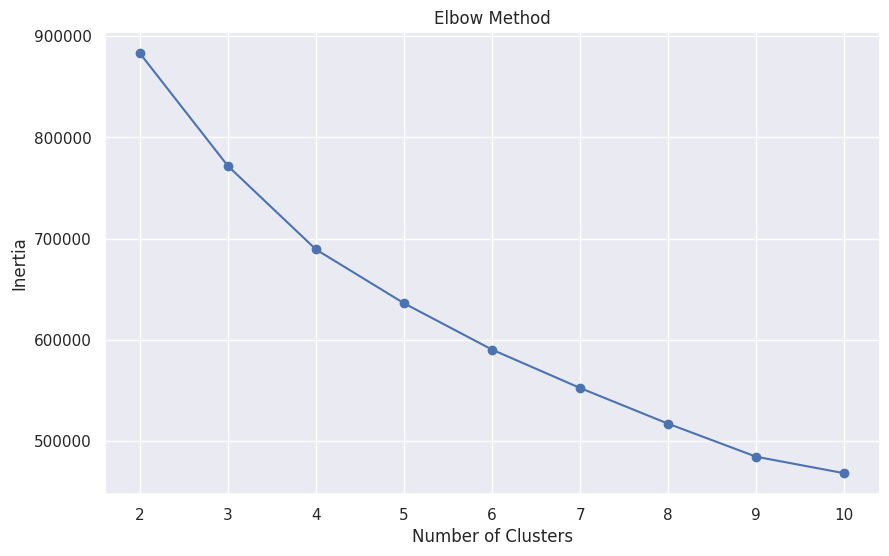

In [ ]:
inertia = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca)
    inertia.append(km.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

The Elbow Method showed that the curve bends at 5 clusters, making
it the optimal number. KMeans was applied on the PCA reduced data
with 5 clusters to group similar songs together based on their
audio features.

In [ ]:
km = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = km.fit_predict(X_pca)

print("Cluster counts:")
print(df['Cluster'].value_counts())

Cluster counts:
Cluster
2    38063
3    30917
4    25360
0    10752
1     8907
Name: count, dtype: int64


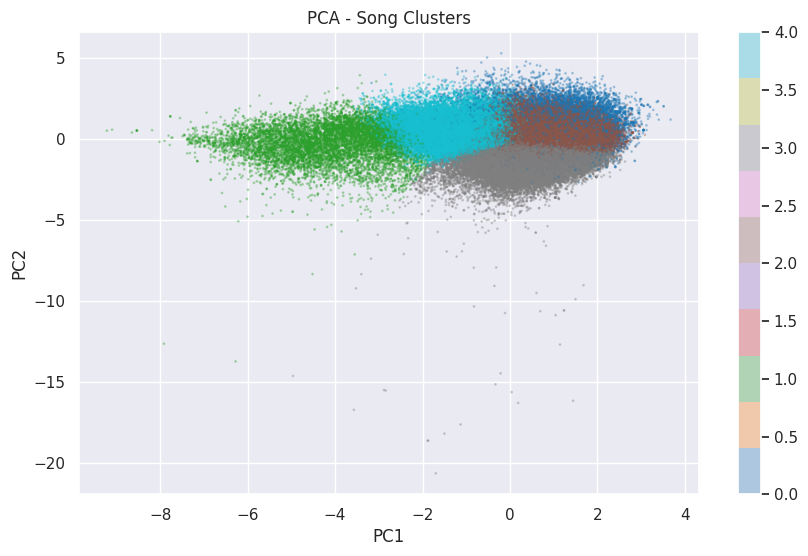

In [ ]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster'], cmap='tab10', alpha=0.3, s=1)
plt.colorbar(scatter)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA - Song Clusters')
plt.show()

The 2D PCA scatter plot shows 5 clusters of songs. Three clusters
are clearly visible and separated while some overlap exists which
is expected in music data as songs can share similar audio features
across different genres.

#STEP 8: MODEL EVALUATION

In [ ]:
score = silhouette_score(X_pca, df['Cluster'])
print("Silhouette Score:", round(score, 4))

db_score = davies_bouldin_score(X_pca, df['Cluster'])
print("Davies Bouldin Score:", round(db_score, 4))

Silhouette Score: 0.1665
Davies Bouldin Score: 1.6466


Silhouette Score of 0.17 indicates mild cluster separation which
is acceptable for music data since songs naturally share similar
audio features across genres. Davies Bouldin Score of 1.65 also
confirms that clusters overlap slightly but are still meaningful
groupings based on audio characteristics.

#STEP 9: HYPERTUNNING

In [ ]:
scores = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    scores.append(score)
    print(f"k={k} → Silhouette Score: {round(score, 4)}")

k=2 → Silhouette Score: 0.243
k=3 → Silhouette Score: 0.2546
k=4 → Silhouette Score: 0.1766
k=5 → Silhouette Score: 0.1665
k=6 → Silhouette Score: 0.1699
k=7 → Silhouette Score: 0.1728
k=8 → Silhouette Score: 0.1818
k=9 → Silhouette Score: 0.1768
k=10 → Silhouette Score: 0.1686


Hyperparameter tuning showed that k=3 gives the highest Silhouette
Score of 0.25 which means 3 clusters produce the most meaningful
and separated groups compared to other values of k.

In [ ]:
km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = km_final.fit_predict(X_pca)

print("Final Cluster counts:")
print(df['Cluster'].value_counts())

Final Cluster counts:
Cluster
1    76672
2    25865
0    11462
Name: count, dtype: int64


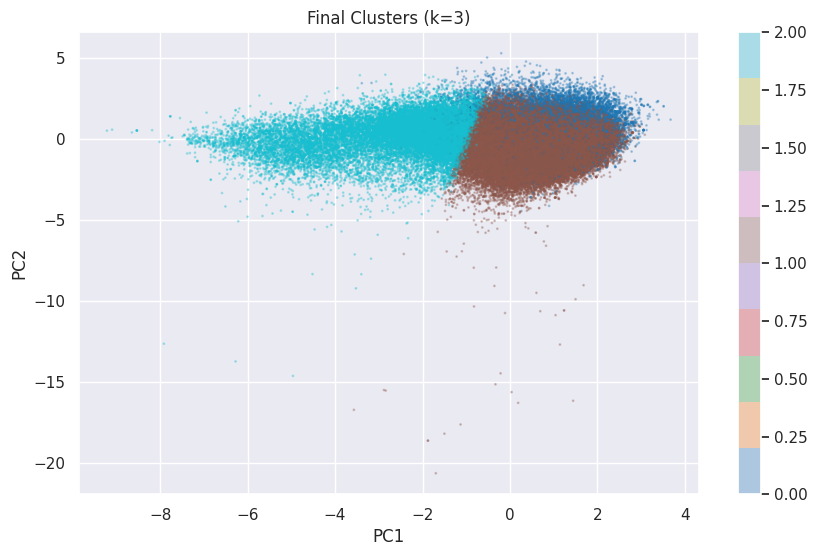

In [ ]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster'], cmap='tab10', alpha=0.3, s=1)
plt.colorbar(scatter)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Final Clusters (k=3)')
plt.show()

The final cluster plot with k=3 shows much better separation compared
to k=5. Cyan cluster is the largest group with low energy acoustic
songs while brown cluster represents high energy songs. This confirms
that 3 is the optimal number of clusters for this dataset.

#STEP 10: PIPELINE BUILDING

In [ ]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=7)),
    ('kmeans', KMeans(n_clusters=3, random_state=42, n_init=10))
])

pipeline.fit(X)
print("Pipeline built successfully!")

Pipeline built successfully!


A sklearn Pipeline was built combining StandardScaler, PCA with 7
components and KMeans with 3 clusters. This pipeline ensures that
any new data goes through the same preprocessing and transformation
steps automatically before prediction.

In [ ]:
df['Cluster'] = pipeline.predict(X)

cluster_summary = df.groupby('Cluster')[features].mean().round(2)
print(cluster_summary)

         danceability  energy  loudness  speechiness  acousticness  \
Cluster                                                              
0               0.640   0.720    -6.710        0.240         0.230   
1               0.590   0.750    -6.390        0.070         0.180   
2               0.470   0.290   -14.500        0.050         0.750   

         instrumentalness  liveness  valence   tempo  popularity  duration_ms  \
Cluster                                                                         
0                   0.050     0.250    0.480 121.560      35.750   202129.460   
1                   0.120     0.220    0.530 126.440      33.580   235610.750   
2                   0.320     0.180    0.310 109.690      31.110   217041.100   

         explicit  
Cluster            
0           0.840  
1           0.000  
2           0.000  


Cluster 0 - High Energy Party Songs: high danceability, high energy,
loud, more explicit content, fast tempo. These are mostly hip hop
and pop party songs.

Cluster 1 - Energetic Clean Songs: high energy, fast tempo, low
speechiness, non explicit. These are mostly rock and electronic songs.

Cluster 2 - Calm Acoustic Songs: low energy, high acousticness,
low loudness, slow tempo. These are mostly acoustic, classical
and ambient songs.

#FINAL CONCLUSION

This project successfully applied Principal Component Analysis (PCA)
on the Spotify Tracks Dataset containing 114,000 songs across 114 genres.

PCA reduced the 12 audio features to 7 principal components while
retaining 80% of the total variance. KMeans clustering with k=3 gave
the best Silhouette Score of 0.25. The final clusters revealed three
distinct song groups: high energy party songs, energetic clean songs,
and calm acoustic songs. This shows that PCA is highly effective in
reducing dimensions while preserving meaningful patterns in music data.